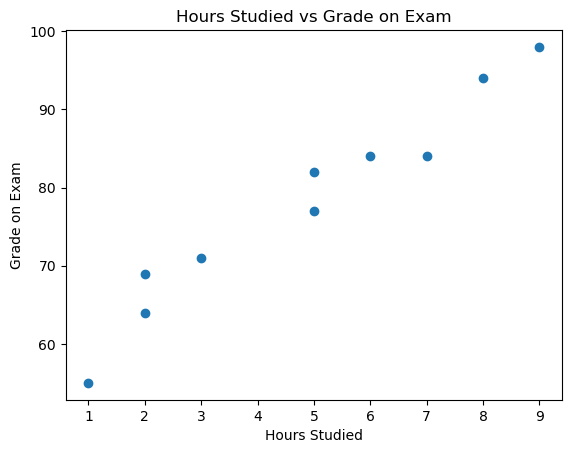

In [1]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.array([2, 9, 5, 5, 3, 7, 1, 8, 6, 2], dtype=float)
grades = np.array([69, 98, 82, 77, 71, 84, 55, 94, 84, 64], dtype=float)

plt.scatter(hours, grades)
plt.xlabel("Hours Studied")
plt.ylabel("Grade on Exam")
plt.title("Hours Studied vs Grade on Exam")
plt.show()

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/regression/test.csv')
df.head()

,Hours Studied,Grade on Exam
0,2,69
1,9,98
2,5,82
3,5,77
4,3,71


In [4]:
x = hours
y = grades

x_mean = x.mean()
y_mean = y.mean()

In [5]:
x_mean

np.float64(4.8)

In [6]:
y_mean

np.float64(77.8)

In [7]:
beta1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
beta0 = y_mean - beta1 * x_mean

print(f"Mean of X: {x_mean:.2f}")
print(f"Mean of Y: {y_mean:.2f}")
print(f"Intercept (β0): {beta0:.4f}")
print(f"Slope (β1): {beta1:.4f}")
print(f"Fitted line: y_hat = {beta0:.2f} + {beta1:.2f}x")

Mean of X: 4.80
Mean of Y: 77.80
Intercept (β0): 55.0355
Slope (β1): 4.7426
Fitted line: y_hat = 55.04 + 4.74x


$$Y^h = \beta_0 + \beta_1 X$$

In [8]:
X = 10

Y_hat = beta0 + beta1*X
print(f'{X} hours of work results {Y_hat}')

10 hours of work results 102.46153846153845


In [9]:
df.sort_values(by='Hours Studied')

,Hours Studied,Grade on Exam
6,1,55
0,2,69
9,2,64
4,3,71
3,5,77
2,5,82
8,6,84
5,7,84
7,8,94
1,9,98


In [10]:
new_hours = 4
predicted_grade = beta0 + beta1 * new_hours

print(f"Predicted grade for {new_hours} hours: {predicted_grade:.2f}")

Predicted grade for 4 hours: 74.01


In [ ]:
#pip install -U scikit-learn

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
X = hours.reshape(-1, 1)
y = grades

hours_model = LinearRegression()
hours_model.fit(X, y)

print(f"Intercept: {hours_model.intercept_:.4f}")
print(f"Slope: {hours_model.coef_[0]:.4f}")

Intercept: 55.0355
Slope: 4.7426


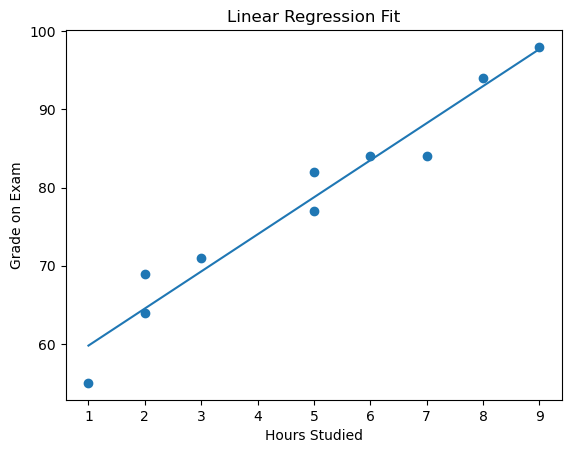

In [15]:
x_line = np.linspace(hours.min(), hours.max(), 100).reshape(-1, 1)
y_line = hours_model.predict(x_line)

plt.scatter(hours, grades)
plt.plot(x_line, y_line)
plt.title("Linear Regression Fit")
plt.xlabel("Hours Studied")
plt.ylabel("Grade on Exam")
plt.show()

In [16]:
y_pred = hours_model.predict(X)
residuals = y - y_pred

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)

r2 = 1 - (ss_res / ss_tot)
rmse = np.sqrt(np.mean(residuals ** 2))

print(f"SS_res: {ss_res:.4f}")
print(f"SS_tot: {ss_tot:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

SS_res: 79.1213
SS_tot: 1599.6000
R-squared: 0.9505
RMSE: 2.8129


In [18]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
r2_sklearn = r2_score(y, y_pred)
rmse_sklearn = np.sqrt(mean_squared_error(y, y_pred))

In [19]:
print(f"R-squared (sklearn): {r2_sklearn:.4f}")
print(f"RMSE (sklearn): {rmse_sklearn:.4f}")

R-squared (sklearn): 0.9505
RMSE (sklearn): 2.8129


In [20]:
import pandas as pd

ads = pd.read_csv('../data/regression/advertising_and_sales.csv')
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [30]:
ads.shape

(4546, 5)

In [33]:
from sklearn.linear_model import LinearRegression

X = ads[['tv']]
y = ads['sales']

model = LinearRegression()
model.fit(X,y)

print(f'intercept: {model.intercept_}')
print(f'coef: {model.coef_}')


intercept: -132.49250561819645
coef: [3.56151409]


$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2$$

In [34]:
X.iloc[0]

tv    16000.0
Name: 0, dtype: float64

In [42]:
def predict(n):
    y_hat = model.intercept_ + model.coef_*X.iloc[n]
    return y_hat

In [44]:
predict(2)

tv    145889.58532
Name: 2, dtype: float64

In [37]:
model.predict(X)

array([ 56851.73298719,  46167.19070729, 145889.58531972, ...,
       156574.12759962, 252735.00811874, 149451.09941302], shape=(4546,))